# Prueba de Progreso 3 - Competición DrivenData: predicción del daño de terremotos

**Autor:** Jorge López Gómez  
**Email:** [Jorge.Lopez32@alu.uclm.es](mailto:Jorge.Lopez32@alu.uclm.es)  
**Asignatura:** Técnicas de Aprendizaje Automático  
**Curso:** 2025/2026  
**Universidad:** UCLM — Talavera de la Reina  
**Fecha:** Abril 2026  
**Repositorio:** [github.com/JorgeLopezGomez/ML-TA-2025-2026-JorgeLopezGomez](https://github.com/JorgeLopezGomez/ML-TA-2025-2026-JorgeLopezGomez)  
**Usuario en DrivenData:** `Jorgegmen`  
**Mejor resultado local obtenido:** `0.752652 Micro F1 local`  
**Mejor modelo local:** `Ensemble_RF_AdaBoost_Bias`  
**Mejor submission pública:** `submission_01_random_forest.csv`  
**Mejor puntuación pública en DrivenData:** `0.7480`  
**Posición en ranking:** `#549`  

---


# 1. Introducción

En este notebook trabajo la competición **Richter's Predictor: Modeling Earthquake Damage**, donde el objetivo es predecir el nivel de daño de un edificio tras un terremoto.

La variable objetivo es `damage_grade` y puede tomar tres valores:

- `1`: daño bajo.
- `2`: daño medio.
- `3`: daño alto.

Lo he planteado como un problema de **clasificación supervisada**, porque en entrenamiento tengo edificios con sus características y su etiqueta real. La métrica principal es **Micro F1**, que en esta competición coincide con la proporción global de aciertos al ser una clasificación multiclase con una única etiqueta por edificio.

Mi idea ha sido mantener un cuaderno claro: revisar los datos, construir variables útiles, comparar varios modelos y quedarme con la submission que mejor funcionó en DrivenData.

# 2. Carga de librerías y configuración

Configuro el entorno al principio para que el notebook sea reproducible y no se quede bloqueado por exceso de hilos. También dejo flags para controlar las partes más pesadas.

In [1]:
# ============================================================
# 3. Carga de librerías y configuración
# ============================================================

# Estas variables se fijan antes de importar librerías numéricas para evitar
# bloqueos por exceso de hilos en algunos entornos de Jupyter/VS Code.
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import gc
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    mean_absolute_error,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

RANDOM_STATE = 42

# Flags principales
RUN_MODELOS_LENTOS = False
RUN_OPTIMIZACION_PESOS_ENSEMBLE = True
MODO_DEBUG = False

TARGET = "damage_grade"
ID_COL = "building_id"
CLASES = np.array([1, 2, 3], dtype=np.int64)

TEST_SIZE_VALIDACION = 0.20
N_SPLITS_TARGET_ENCODING = 5
N_DEBUG_TRAIN = 60_000

RF_N_ESTIMATORS = 450 if not MODO_DEBUG else 80
ADABOOST_N_ESTIMATORS = 90 if not MODO_DEBUG else 25
ADABOOST_LEARNING_RATE = 0.08

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_STATE)

print("Configuración cargada correctamente")
print(f"RUN_MODELOS_LENTOS = {RUN_MODELOS_LENTOS}")
print(f"RUN_OPTIMIZACION_PESOS_ENSEMBLE = {RUN_OPTIMIZACION_PESOS_ENSEMBLE}")
print(f"MODO_DEBUG = {MODO_DEBUG}")
print(f"RF_N_ESTIMATORS = {RF_N_ESTIMATORS}")
print(f"ADABOOST_N_ESTIMATORS = {ADABOOST_N_ESTIMATORS}")
print(f"OUTPUT_DIR = {OUTPUT_DIR.resolve()}")


Configuración cargada correctamente
RUN_MODELOS_LENTOS = False
RUN_OPTIMIZACION_PESOS_ENSEMBLE = True
MODO_DEBUG = False
RF_N_ESTIMATORS = 450
ADABOOST_N_ESTIMATORS = 90
OUTPUT_DIR = /home/jorgegmen/Documentos/GitHub/ML-TA-2025-2026-JorgeLopezGomez/P3_Datathon/outputs


# 3. Carga y comprobación de datos

Cargo los cuatro CSV oficiales y hago las comprobaciones básicas antes de modelar: dimensiones, nulos, duplicados, tipos y coincidencia de `building_id`.

In [2]:
# ============================================================
# 4. Carga de datos
# ============================================================

def buscar_fichero(nombre_fichero, carpetas=None):
    """Busca un fichero en varias carpetas habituales."""
    if carpetas is None:
        carpetas = [Path("data"), Path("../data"), Path("."), Path("/mnt/data")]

    for carpeta in carpetas:
        ruta = carpeta / nombre_fichero
        if ruta.exists():
            return ruta

    raise FileNotFoundError(
        f"No se encontró {nombre_fichero}. Carpetas revisadas: {[str(c) for c in carpetas]}"
    )


paths = {
    "train_values": buscar_fichero("train_values.csv"),
    "train_labels": buscar_fichero("train_labels.csv"),
    "test_values": buscar_fichero("test_values.csv"),
    "submission_format": buscar_fichero("submission_format.csv"),
}

for nombre, ruta in paths.items():
    print(f"{nombre:18s} -> {ruta}")

train_values = pd.read_csv(paths["train_values"])
train_labels = pd.read_csv(paths["train_labels"])
test_values = pd.read_csv(paths["test_values"])
submission_format = pd.read_csv(paths["submission_format"])

train_df = train_values.merge(train_labels, on=ID_COL, how="inner")

if MODO_DEBUG:
    train_df = (
        train_df
        .sample(n=min(N_DEBUG_TRAIN, len(train_df)), random_state=RANDOM_STATE)
        .sort_index()
        .reset_index(drop=True)
    )
    train_values = train_df.drop(columns=[TARGET]).copy()
    train_labels = train_df[[ID_COL, TARGET]].copy()

print("\nDatos cargados:")
print(f"train_values:      {train_values.shape}")
print(f"train_labels:      {train_labels.shape}")
print(f"train_df:          {train_df.shape}")
print(f"test_values:       {test_values.shape}")
print(f"submission_format: {submission_format.shape}")

# ============================================================
# 4.1. Comprobaciones de integridad
# ============================================================

def resumen_basico(df, nombre):
    return pd.Series({
        "tabla": nombre,
        "filas": df.shape[0],
        "columnas": df.shape[1],
        "nulos": int(df.isna().sum().sum()),
        "duplicados_fila": int(df.duplicated().sum()),
        "building_id_unicos": int(df[ID_COL].nunique()) if ID_COL in df.columns else np.nan,
        "building_id_duplicados": int(df[ID_COL].duplicated().sum()) if ID_COL in df.columns else np.nan,
    })


resumenes = pd.DataFrame([
    resumen_basico(train_values, "train_values"),
    resumen_basico(train_labels, "train_labels"),
    resumen_basico(test_values, "test_values"),
    resumen_basico(submission_format, "submission_format"),
])
display(resumenes)

assert train_values[ID_COL].is_unique
assert train_labels[ID_COL].is_unique
assert test_values[ID_COL].is_unique
assert submission_format[ID_COL].is_unique
assert set(train_values[ID_COL]) == set(train_labels[ID_COL])
assert test_values[ID_COL].equals(submission_format[ID_COL])

print("Comprobaciones superadas: IDs únicos, sin desorden en test y formato de submission correcto.")

tipos = train_values.drop(columns=[ID_COL]).dtypes.value_counts().rename_axis("tipo").reset_index(name="n_columnas")
display(tipos)


train_values       -> data/train_values.csv
train_labels       -> data/train_labels.csv
test_values        -> data/test_values.csv
submission_format  -> data/submission_format.csv

Datos cargados:
train_values:      (260601, 39)
train_labels:      (260601, 2)
train_df:          (260601, 40)
test_values:       (86868, 39)
submission_format: (86868, 2)


,tabla,filas,columnas,nulos,duplicados_fila,building_id_unicos,building_id_duplicados
0,train_values,260601,39,0,0,260601,0
1,train_labels,260601,2,0,0,260601,0
2,test_values,86868,39,0,0,86868,0
3,submission_format,86868,2,0,0,86868,0


Comprobaciones superadas: IDs únicos, sin desorden en test y formato de submission correcto.


,tipo,n_columnas
0,int64,30
1,str,8


# 4. Análisis exploratorio resumido

Mantengo un EDA corto: distribución de la variable objetivo, resumen de variables y comparación básica entre train y test. Con esto basta para entender el problema sin alargar demasiado el notebook.

,tipo,n_columnas
0,categóricas,8
1,numéricas no binarias,8
2,binarias,22


,damage_grade,n,porcentaje
0,1,25124,9.640792
1,2,148259,56.891186
2,3,87218,33.468022


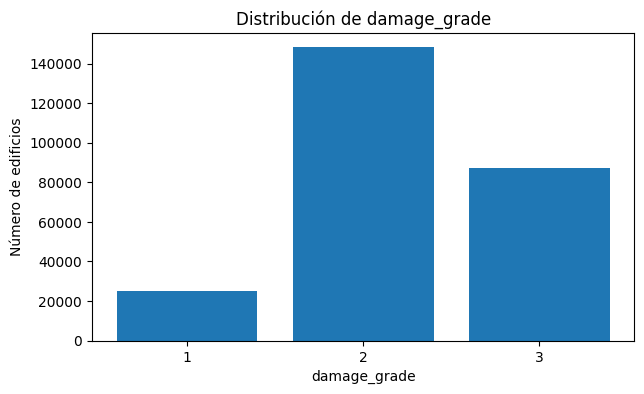

,variable,media_train,media_test,dif_abs_media
2,geo_level_3_id,6257.876148,6261.758565,3.882417
1,geo_level_2_id,701.074685,704.128125,3.053440
4,age,26.535029,26.550168,0.015139
0,geo_level_1_id,13.900353,13.888198,0.012155
5,area_percentage,8.018051,8.013906,0.004144
3,count_floors_pre_eq,2.129723,2.133145,0.003421
6,height_percentage,5.434365,5.436098,0.001733
14,has_superstructure_timber,0.254988,0.253534,0.001453
13,has_superstructure_cement_mortar_brick,0.075268,0.073836,0.001432
15,has_superstructure_bamboo,0.085011,0.083679,0.001333


,variable,distancia_train_test,categorias_train,categorias_test
4,other_floor_type,0.003486,4,4
1,foundation_type,0.002472,5,5
2,roof_type,0.002263,3,3
6,plan_configuration,0.001554,10,10
3,ground_floor_type,0.001437,5,5
0,land_surface_condition,0.000842,3,3
7,legal_ownership_status,0.000837,4,4
5,position,0.000830,4,4


damage_grade,1,2,3
age,17.320490,27.342118,27.817423
area_percentage,9.716009,8.034049,7.501743
height_percentage,5.147349,5.432345,5.520477
count_floors_pre_eq,1.841307,2.131763,2.209338
count_families,0.915101,0.982018,1.007063
has_superstructure_mud_mortar_stone,0.348671,0.768567,0.869706
has_superstructure_timber,0.304171,0.271059,0.213500
has_secondary_use,0.169081,0.119487,0.082472


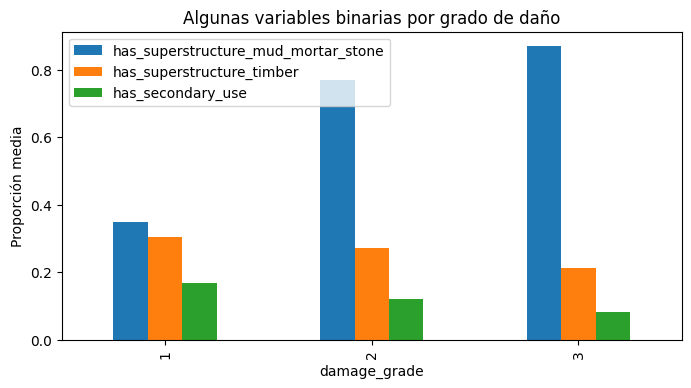

In [3]:
# ============================================================
# 5. Tipos de variables y distribución del objetivo
# ============================================================

feature_cols = [c for c in train_values.columns if c != ID_COL]

cat_cols = train_values[feature_cols].select_dtypes(include="object").columns.tolist()
num_cols = train_values[feature_cols].select_dtypes(exclude="object").columns.tolist()
binary_cols = [c for c in num_cols if set(train_values[c].dropna().unique()).issubset({0, 1})]
numeric_non_binary_cols = [c for c in num_cols if c not in binary_cols]

display(pd.DataFrame({
    "tipo": ["categóricas", "numéricas no binarias", "binarias"],
    "n_columnas": [len(cat_cols), len(numeric_non_binary_cols), len(binary_cols)]
}))

dist_target = train_df[TARGET].value_counts().sort_index().rename_axis(TARGET).reset_index(name="n")
dist_target["porcentaje"] = 100 * dist_target["n"] / dist_target["n"].sum()
display(dist_target)

plt.figure(figsize=(7, 4))
plt.bar(dist_target[TARGET].astype(str), dist_target["n"])
plt.title("Distribución de damage_grade")
plt.xlabel("damage_grade")
plt.ylabel("Número de edificios")
plt.show()

# ============================================================
# 5.1. Comparación resumida train/test
# ============================================================

def distancia_distribuciones_categoricas(s_train, s_test):
    """Distancia de variación total entre dos distribuciones categóricas."""
    p = s_train.astype(str).value_counts(normalize=True)
    q = s_test.astype(str).value_counts(normalize=True)
    idx = p.index.union(q.index)
    return 0.5 * np.abs(p.reindex(idx, fill_value=0) - q.reindex(idx, fill_value=0)).sum()


comparacion_num = []
for col in numeric_non_binary_cols + binary_cols:
    comparacion_num.append({
        "variable": col,
        "media_train": train_values[col].mean(),
        "media_test": test_values[col].mean(),
        "dif_abs_media": abs(train_values[col].mean() - test_values[col].mean()),
    })

comparacion_num = pd.DataFrame(comparacion_num).sort_values("dif_abs_media", ascending=False)
display(comparacion_num.head(15))

comparacion_cat = []
for col in cat_cols:
    comparacion_cat.append({
        "variable": col,
        "distancia_train_test": distancia_distribuciones_categoricas(train_values[col], test_values[col]),
        "categorias_train": train_values[col].nunique(),
        "categorias_test": test_values[col].nunique(),
    })

comparacion_cat = pd.DataFrame(comparacion_cat).sort_values("distancia_train_test", ascending=False)
display(comparacion_cat)

# ============================================================
# 5.2. Perfil medio por clase
# ============================================================

cols_perfil = [
    "age", "area_percentage", "height_percentage", "count_floors_pre_eq",
    "count_families", "has_superstructure_mud_mortar_stone",
    "has_superstructure_timber", "has_secondary_use"
]
cols_perfil = [c for c in cols_perfil if c in train_df.columns]

perfil_clase = train_df.groupby(TARGET)[cols_perfil].mean().T
display(perfil_clase)

perfil_clase.loc[[c for c in cols_perfil if c.startswith("has_")]].T.plot(kind="bar", figsize=(8, 4))
plt.title("Algunas variables binarias por grado de daño")
plt.xlabel("damage_grade")
plt.ylabel("Proporción media")
plt.show()


# 5. Preprocesamiento e ingeniería de características

El identificador `building_id` se conserva para crear el envío final, pero no se usa como predictor directo.

Las variables añadidas buscan capturar información sencilla pero útil:

- recuento de tipos de superestructura;
- recuento de usos secundarios;
- ratios de tamaño, área y altura;
- edad acotada y transformada;
- combinaciones geográficas y constructivas;
- `frequency encoding`;
- `target encoding` multiclase con folds out-of-fold para evitar fuga de información.

In [4]:
# ============================================================
# 6. Preprocesamiento e ingeniería de características
# ============================================================

def safe_divide(a, b):
    """División segura para evitar divisiones por cero."""
    return a / np.where(b == 0, 1, b)


def crear_variables_derivadas(df):
    """Crea variables competitivas a partir de las columnas originales."""
    out = df.copy()

    super_cols = [c for c in out.columns if c.startswith("has_superstructure_")]
    secondary_cols = [c for c in out.columns if c.startswith("has_secondary_use_")]

    out["n_superestructuras"] = out[super_cols].sum(axis=1).astype(np.int16)
    out["n_usos_secundarios"] = out[secondary_cols].sum(axis=1).astype(np.int16)

    out["age_clip_100"] = out["age"].clip(0, 100)
    out["age_log1p"] = np.log1p(out["age_clip_100"])
    out["edificio_nuevo"] = (out["age"] == 0).astype(np.int8)
    out["edificio_antiguo"] = (out["age"] >= 30).astype(np.int8)
    out["edificio_muy_antiguo"] = (out["age"] >= 60).astype(np.int8)

    out["area_por_planta"] = safe_divide(out["area_percentage"], out["count_floors_pre_eq"])
    out["altura_por_planta"] = safe_divide(out["height_percentage"], out["count_floors_pre_eq"])
    out["volumen_aprox"] = out["area_percentage"] * out["height_percentage"]
    out["familias_por_area"] = safe_divide(out["count_families"], out["area_percentage"])

    out["geo_1_2"] = out["geo_level_1_id"].astype(str) + "_" + out["geo_level_2_id"].astype(str)
    out["geo_2_3"] = out["geo_level_2_id"].astype(str) + "_" + out["geo_level_3_id"].astype(str)
    out["geo_1_2_3"] = (
        out["geo_level_1_id"].astype(str) + "_" +
        out["geo_level_2_id"].astype(str) + "_" +
        out["geo_level_3_id"].astype(str)
    )

    out["foundation_roof"] = out["foundation_type"].astype(str) + "_" + out["roof_type"].astype(str)
    out["floor_combo"] = out["ground_floor_type"].astype(str) + "_" + out["other_floor_type"].astype(str)
    out["position_plan"] = out["position"].astype(str) + "_" + out["plan_configuration"].astype(str)

    return out


class EarthquakePreprocessor:
    """Preprocesador compacto para la competición de terremotos."""

    def __init__(self, classes, n_splits=5, smoothing=30, random_state=42):
        self.classes = np.asarray(classes)
        self.n_splits = n_splits
        self.smoothing = smoothing
        self.random_state = random_state

    def _preparar_columnas(self, X):
        self.cat_cols_ = X.select_dtypes(include="object").columns.tolist()
        self.num_cols_ = [c for c in X.columns if c not in self.cat_cols_ and c != ID_COL]

        self.freq_cols_ = self.cat_cols_ + [
            c for c in ["geo_level_1_id", "geo_level_2_id", "geo_level_3_id"] if c in X.columns
        ]

        self.te_cols_ = [
            c for c in [
                "geo_level_1_id", "geo_level_2_id", "geo_level_3_id",
                "geo_1_2", "geo_2_3", "geo_1_2_3",
                "foundation_type", "roof_type", "foundation_roof", "floor_combo"
            ]
            if c in X.columns
        ]

    def _fit_codificadores_basicos(self, X):
        self.category_maps_ = {}
        for col in self.cat_cols_:
            valores = pd.Series(X[col].astype(str).unique()).sort_values().tolist()
            self.category_maps_[col] = {v: i for i, v in enumerate(valores)}

        self.freq_maps_ = {}
        for col in self.freq_cols_:
            self.freq_maps_[col] = X[col].astype(str).value_counts(normalize=True).to_dict()

    def _transform_basico(self, X):
        partes = []

        base_num = X[self.num_cols_].copy()
        partes.append(base_num)

        for col in self.cat_cols_:
            cod = X[col].astype(str).map(self.category_maps_[col]).fillna(-1).astype(np.float32)
            partes.append(pd.DataFrame({f"{col}_ord": cod}, index=X.index))

        for col in self.freq_cols_:
            freq = X[col].astype(str).map(self.freq_maps_[col]).fillna(0).astype(np.float32)
            partes.append(pd.DataFrame({f"{col}_freq": freq}, index=X.index))

        return pd.concat(partes, axis=1)

    def _calcular_mapas_te(self, X, y):
        mapas = {}
        y = pd.Series(y, index=X.index)

        for cls in self.classes:
            y_bin = (y == cls).astype(float)
            global_mean = float(y_bin.mean())

            for col in self.te_cols_:
                tmp = pd.DataFrame({"col": X[col].astype(str), "target": y_bin})
                stats = tmp.groupby("col")["target"].agg(["mean", "count"])
                smooth = (stats["mean"] * stats["count"] + global_mean * self.smoothing) / (stats["count"] + self.smoothing)

                mapas[(col, int(cls))] = {
                    "map": smooth.to_dict(),
                    "global": global_mean,
                }

        return mapas

    def _target_encoding_oof(self, X, y):
        y = pd.Series(y, index=X.index)
        te = pd.DataFrame(index=X.index)

        for col in self.te_cols_:
            for cls in self.classes:
                te[f"{col}_te_cls_{cls}"] = np.nan

        skf = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)

        for tr_idx, va_idx in skf.split(X, y):
            X_tr = X.iloc[tr_idx]
            y_tr = y.iloc[tr_idx]
            X_va = X.iloc[va_idx]

            mapas_fold = self._calcular_mapas_te(X_tr, y_tr)

            for col in self.te_cols_:
                valores = X_va[col].astype(str)
                for cls in self.classes:
                    info = mapas_fold[(col, int(cls))]
                    te.iloc[va_idx, te.columns.get_loc(f"{col}_te_cls_{cls}")] = (
                        valores.map(info["map"]).fillna(info["global"]).values
                    )

        return te.astype(np.float32)

    def _target_encoding_transform(self, X):
        te = pd.DataFrame(index=X.index)

        for col in self.te_cols_:
            valores = X[col].astype(str)
            for cls in self.classes:
                info = self.te_maps_[(col, int(cls))]
                te[f"{col}_te_cls_{cls}"] = valores.map(info["map"]).fillna(info["global"]).astype(np.float32)

        return te

    def fit_transform(self, X, y):
        X_feat = crear_variables_derivadas(X).reset_index(drop=True)
        y = pd.Series(y).reset_index(drop=True)

        self._preparar_columnas(X_feat)
        self._fit_codificadores_basicos(X_feat)

        base = self._transform_basico(X_feat)
        te = self._target_encoding_oof(X_feat, y)
        matriz = pd.concat([base, te], axis=1).replace([np.inf, -np.inf], 0).fillna(0)

        self.te_maps_ = self._calcular_mapas_te(X_feat, y)
        self.scaler_ = MinMaxScaler()
        matriz_scaled = self.scaler_.fit_transform(matriz).astype(np.float32)

        self.feature_names_ = matriz.columns.tolist()
        return pd.DataFrame(matriz_scaled, columns=self.feature_names_)

    def transform(self, X):
        X_feat = crear_variables_derivadas(X).reset_index(drop=True)

        base = self._transform_basico(X_feat)
        te = self._target_encoding_transform(X_feat)
        matriz = pd.concat([base, te], axis=1).replace([np.inf, -np.inf], 0).fillna(0)

        matriz_scaled = self.scaler_.transform(matriz).astype(np.float32)
        return pd.DataFrame(matriz_scaled, columns=self.feature_names_)


# 6. Validación local

Se separa un 20 % de los datos con `train_test_split` estratificado. La métrica principal es **Micro F1**, y además uso `F1 macro` y `MAE ordinal` para interpretar mejor los errores.

In [5]:
# ============================================================
# 7. Partición de validación y preprocesamiento
# ============================================================

X_raw = train_df.drop(columns=[TARGET]).copy()
y = train_df[TARGET].astype(int).copy()

X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X_raw,
    y,
    test_size=TEST_SIZE_VALIDACION,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"X_train_raw: {X_train_raw.shape}")
print(f"X_valid_raw: {X_valid_raw.shape}")

display(pd.DataFrame({
    "train": y_train.value_counts(normalize=True).sort_index(),
    "valid": y_valid.value_counts(normalize=True).sort_index(),
}))

preprocessor = EarthquakePreprocessor(
    classes=CLASES,
    n_splits=N_SPLITS_TARGET_ENCODING,
    smoothing=30,
    random_state=RANDOM_STATE,
)

inicio = time.time()
X_train = preprocessor.fit_transform(X_train_raw, y_train)
X_valid = preprocessor.transform(X_valid_raw)
tiempo_prep = time.time() - inicio

print(f"X_train procesado: {X_train.shape} | dtype={X_train.dtypes.iloc[0]}")
print(f"X_valid procesado: {X_valid.shape} | dtype={X_valid.dtypes.iloc[0]}")
print(f"Tiempo de preprocesamiento: {tiempo_prep:.2f} s")
print(f"Memoria aproximada X_train: {X_train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# ============================================================
# 7.1. Funciones de evaluación
# ============================================================

resultados = []
modelos_entrenados = {}
pred_valid = {}
proba_valid = {}

def evaluar_predicciones(y_true, y_pred, nombre_modelo, tiempo_s=None):
    """Calcula las métricas usadas para comparar modelos."""
    return {
        "modelo": nombre_modelo,
        "micro_f1": f1_score(y_true, y_pred, average="micro"),
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "mae_ordinal": mean_absolute_error(y_true, y_pred),
        "tiempo_s": tiempo_s,
    }


def proba_alineada(modelo, X, clases=CLASES):
    """Devuelve predict_proba con columnas ordenadas como CLASES."""
    proba = modelo.predict_proba(X)
    salida = np.zeros((len(X), len(clases)), dtype=np.float32)

    for i, cls in enumerate(modelo.classes_):
        pos = np.where(clases == cls)[0][0]
        salida[:, pos] = proba[:, i]

    return salida


def entrenar_y_evaluar(modelo, nombre, X_tr, y_tr, X_va, y_va):
    """Entrena un modelo, predice validación y guarda métricas."""
    print(f"\nEntrenando {nombre}...")
    inicio = time.time()
    modelo.fit(X_tr, y_tr)
    tiempo_s = time.time() - inicio

    pred = modelo.predict(X_va)
    metricas = evaluar_predicciones(y_va, pred, nombre, tiempo_s)

    resultados.append(metricas)
    modelos_entrenados[nombre] = modelo
    pred_valid[nombre] = pred

    if hasattr(modelo, "predict_proba"):
        proba_valid[nombre] = proba_alineada(modelo, X_va)

    print(
        f"{nombre}: Micro F1={metricas['micro_f1']:.5f} | "
        f"F1 macro={metricas['f1_macro']:.5f} | "
        f"MAE ordinal={metricas['mae_ordinal']:.5f} | "
        f"tiempo={tiempo_s:.2f}s"
    )

    return modelo


X_train_raw: (208480, 39)
X_valid_raw: (52121, 39)


,train,valid
damage_grade,,
1,0.096407,0.096410
2,0.568913,0.568907
3,0.334680,0.334683


X_train procesado: (208480, 102) | dtype=float32
X_valid procesado: (52121, 102) | dtype=float32
Tiempo de preprocesamiento: 8.89 s
Memoria aproximada X_train: 81.12 MB


# 7. Modelos probados

Pruebo una selección de modelos suficiente para comparar sin hacer el cuaderno demasiado largo:

- `DummyClassifier`, como referencia mínima.
- `DecisionTreeClassifier`, modelo interpretable.
- `GaussianNB`, prueba rápida.
- `RandomForestClassifier`, modelo principal.
- `AdaBoostClassifier`, boosting con árboles pequeños.

KNN no se ejecuta porque el dataset es grande y este método calcula distancias contra muchas instancias, por lo que no compensa para esta entrega.


Entrenando DummyClassifier...
DummyClassifier: Micro F1=0.56891 | F1 macro=0.24174 | MAE ordinal=0.43109 | tiempo=0.00s

Entrenando DecisionTreeClassifier...
DecisionTreeClassifier: Micro F1=0.71735 | F1 macro=0.66326 | MAE ordinal=0.28846 | tiempo=7.47s

Entrenando GaussianNB...
GaussianNB: Micro F1=0.49583 | F1 macro=0.49371 | MAE ordinal=0.52457 | tiempo=0.13s

Entrenando RandomForestClassifier...
RandomForestClassifier: Micro F1=0.75200 | F1 macro=0.70090 | MAE ordinal=0.25141 | tiempo=59.20s

Entrenando AdaBoostClassifier...
AdaBoostClassifier: Micro F1=0.72485 | F1 macro=0.63943 | MAE ordinal=0.27739 | tiempo=98.35s


,modelo,micro_f1,accuracy,f1_macro,mae_ordinal,tiempo_s
0,RandomForestClassifier,0.752000,0.752000,0.700901,0.251415,59.200800
1,AdaBoostClassifier,0.724852,0.724852,0.639426,0.277393,98.345078
2,DecisionTreeClassifier,0.717350,0.717350,0.663262,0.288463,7.474967
3,DummyClassifier,0.568907,0.568907,0.241742,0.431093,0.003370
4,GaussianNB,0.495827,0.495827,0.493708,0.524568,0.134063


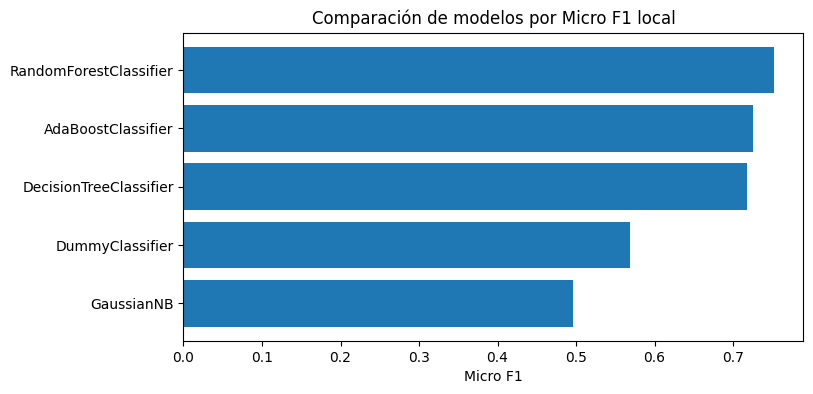

In [6]:
# ============================================================
# 8. Entrenamiento de los modelos principales
# ============================================================

def crear_adaboost():
    """Crea AdaBoost usando árboles pequeños como clasificadores débiles."""
    arbol_debil = DecisionTreeClassifier(
        criterion="gini",
        max_depth=2,
        min_samples_leaf=40,
        random_state=RANDOM_STATE,
    )

    return AdaBoostClassifier(
        estimator=arbol_debil,
        n_estimators=ADABOOST_N_ESTIMATORS,
        learning_rate=ADABOOST_LEARNING_RATE,
        random_state=RANDOM_STATE,
    )


modelos = {
    "DummyClassifier": DummyClassifier(
        strategy="most_frequent",
        random_state=RANDOM_STATE,
    ),

    "DecisionTreeClassifier": DecisionTreeClassifier(
        criterion="gini",
        max_depth=18,
        min_samples_split=40,
        min_samples_leaf=15,
        random_state=RANDOM_STATE,
    ),

    "GaussianNB": GaussianNB(),

    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS,
        criterion="gini",
        max_features="sqrt",
        min_samples_leaf=2,
        bootstrap=True,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=0,
    ),

    "AdaBoostClassifier": crear_adaboost(),
}

for nombre, modelo in modelos.items():
    entrenar_y_evaluar(modelo, nombre, X_train, y_train, X_valid, y_valid)

resultados_df = pd.DataFrame(resultados).sort_values("micro_f1", ascending=False).reset_index(drop=True)
display(resultados_df)

plt.figure(figsize=(8, 4))
plt.barh(resultados_df["modelo"], resultados_df["micro_f1"])
plt.title("Comparación de modelos por Micro F1 local")
plt.xlabel("Micro F1")
plt.gca().invert_yaxis()
plt.show()


# 8. Ensemble y selección local

Además de los modelos individuales, combino Random Forest y AdaBoost usando sus probabilidades. Primero busco el peso que maximiza Micro F1 en validación y después aplico un pequeño ajuste por clase.

In [7]:
# ============================================================
# 9. Ensemble RF + AdaBoost
# ============================================================

def predecir_desde_proba(proba, clases=CLASES):
    return clases[np.argmax(proba, axis=1)]


def optimizar_peso_ensemble(proba_rf, proba_ada, y_true, grid=None):
    if grid is None:
        grid = np.linspace(0.0, 1.0, 41)

    registros = []
    for w_rf in grid:
        proba = w_rf * proba_rf + (1.0 - w_rf) * proba_ada
        pred = predecir_desde_proba(proba)

        registros.append({
            "peso_rf": w_rf,
            "peso_adaboost": 1.0 - w_rf,
            "micro_f1": f1_score(y_true, pred, average="micro"),
            "f1_macro": f1_score(y_true, pred, average="macro"),
            "mae_ordinal": mean_absolute_error(y_true, pred),
        })

    return pd.DataFrame(registros).sort_values("micro_f1", ascending=False).reset_index(drop=True)


def buscar_bias_clases(proba_base, y_true, valores=None):
    if valores is None:
        valores = [0.94, 0.97, 1.00, 1.03, 1.06]

    registros = []
    for b1 in valores:
        for b2 in valores:
            for b3 in valores:
                bias = np.array([b1, b2, b3], dtype=np.float32)
                proba = proba_base * bias
                pred = predecir_desde_proba(proba)

                registros.append({
                    "bias_1": b1,
                    "bias_2": b2,
                    "bias_3": b3,
                    "micro_f1": f1_score(y_true, pred, average="micro"),
                    "f1_macro": f1_score(y_true, pred, average="macro"),
                    "mae_ordinal": mean_absolute_error(y_true, pred),
                })

    return pd.DataFrame(registros).sort_values("micro_f1", ascending=False).reset_index(drop=True)


proba_rf = proba_valid["RandomForestClassifier"]
proba_ada = proba_valid["AdaBoostClassifier"]

if RUN_OPTIMIZACION_PESOS_ENSEMBLE:
    pesos_df = optimizar_peso_ensemble(proba_rf, proba_ada, y_valid)
    display(pesos_df.head(10))
    mejor_peso_rf = float(pesos_df.loc[0, "peso_rf"])
else:
    mejor_peso_rf = 0.85

proba_ensemble = mejor_peso_rf * proba_rf + (1.0 - mejor_peso_rf) * proba_ada
pred_ensemble = predecir_desde_proba(proba_ensemble)

metricas_ensemble = evaluar_predicciones(y_valid, pred_ensemble, "Ensemble_RF_AdaBoost")
resultados.append(metricas_ensemble)
pred_valid["Ensemble_RF_AdaBoost"] = pred_ensemble
proba_valid["Ensemble_RF_AdaBoost"] = proba_ensemble

bias_df = buscar_bias_clases(proba_ensemble, y_valid)
display(bias_df.head(10))

mejor_bias = bias_df.loc[0, ["bias_1", "bias_2", "bias_3"]].to_numpy(dtype=np.float32)
proba_ensemble_bias = proba_ensemble * mejor_bias
pred_ensemble_bias = predecir_desde_proba(proba_ensemble_bias)

metricas_ensemble_bias = evaluar_predicciones(y_valid, pred_ensemble_bias, "Ensemble_RF_AdaBoost_Bias")
resultados.append(metricas_ensemble_bias)
pred_valid["Ensemble_RF_AdaBoost_Bias"] = pred_ensemble_bias
proba_valid["Ensemble_RF_AdaBoost_Bias"] = proba_ensemble_bias

resultados_df = (
    pd.DataFrame(resultados)
    .drop_duplicates(subset=["modelo"], keep="last")
    .sort_values("micro_f1", ascending=False)
    .reset_index(drop=True)
)

display(resultados_df)

mejor_modelo_nombre = resultados_df.loc[0, "modelo"]
mejor_micro_f1_local = float(resultados_df.loc[0, "micro_f1"])

print(f"Mejor peso RF: {mejor_peso_rf:.3f}")
print(f"Mejor peso AdaBoost: {1.0 - mejor_peso_rf:.3f}")
print(f"Mejor bias por clase [1, 2, 3]: {mejor_bias}")
print(f"Mejor estrategia local: {mejor_modelo_nombre} | Micro F1={mejor_micro_f1_local:.6f}")


,peso_rf,peso_adaboost,micro_f1,f1_macro,mae_ordinal
0,0.675,0.325,0.752173,0.699643,0.251050
1,0.650,0.350,0.752134,0.699551,0.251031
2,0.900,0.100,0.752096,0.700706,0.251242
3,0.875,0.125,0.752077,0.700601,0.251242
4,0.975,0.025,0.752058,0.700839,0.251338
5,0.725,0.275,0.752058,0.699835,0.251185
6,0.925,0.075,0.752039,0.700692,0.251319
7,0.525,0.475,0.752019,0.698598,0.251050
8,0.700,0.300,0.752000,0.699694,0.251223
9,0.775,0.225,0.752000,0.699944,0.251281


,bias_1,bias_2,bias_3,micro_f1,f1_macro,mae_ordinal
0,1.00,1.03,1.06,0.752652,0.699564,0.250532
1,0.97,1.00,1.03,0.752633,0.699489,0.250571
2,0.94,0.97,1.00,0.752537,0.699473,0.250648
3,1.00,1.03,1.03,0.752403,0.698764,0.250667
4,0.97,1.03,1.06,0.752403,0.697484,0.250705
5,1.03,1.06,1.06,0.752403,0.698764,0.250667
6,1.00,1.00,1.03,0.752384,0.700410,0.250993
7,0.94,0.97,0.97,0.752384,0.698663,0.250686
8,1.03,1.03,1.06,0.752384,0.700396,0.250974
9,0.97,1.00,1.00,0.752365,0.698615,0.250724


,modelo,micro_f1,accuracy,f1_macro,mae_ordinal,tiempo_s
0,Ensemble_RF_AdaBoost_Bias,0.752652,0.752652,0.699564,0.250532,NaN
1,Ensemble_RF_AdaBoost,0.752173,0.752173,0.699643,0.251050,NaN
2,RandomForestClassifier,0.752000,0.752000,0.700901,0.251415,59.200800
3,AdaBoostClassifier,0.724852,0.724852,0.639426,0.277393,98.345078
4,DecisionTreeClassifier,0.717350,0.717350,0.663262,0.288463,7.474967
5,DummyClassifier,0.568907,0.568907,0.241742,0.431093,0.003370
6,GaussianNB,0.495827,0.495827,0.493708,0.524568,0.134063


Mejor peso RF: 0.675
Mejor peso AdaBoost: 0.325
Mejor bias por clase [1, 2, 3]: [1.   1.03 1.06]
Mejor estrategia local: Ensemble_RF_AdaBoost_Bias | Micro F1=0.752652


# 9. Interpretación del modelo

Reviso la matriz de confusión, el informe de clasificación y la importancia de variables de Random Forest. Esto ayuda a explicar qué está aprendiendo el modelo y dónde se equivoca.

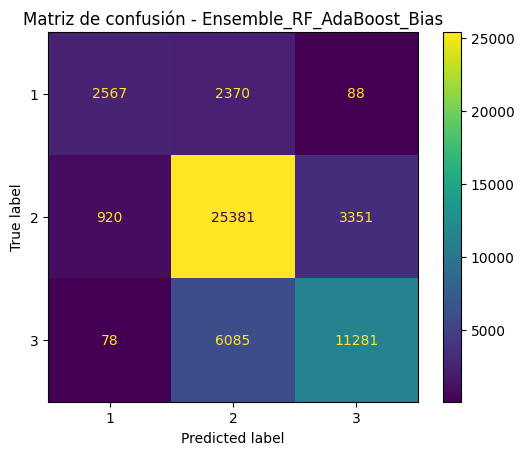

              precision    recall  f1-score   support

           1     0.7201    0.5108    0.5977      5025
           2     0.7501    0.8560    0.7996     29652
           3     0.7664    0.6467    0.7015     17444

    accuracy                         0.7527     52121
   macro avg     0.7455    0.6712    0.6996     52121
weighted avg     0.7527    0.7527    0.7473     52121



,variable,importancia
0,geo_1_2_3_te_cls_3,0.049944
1,geo_2_3_te_cls_3,0.047305
2,geo_level_3_id_te_cls_3,0.046602
3,geo_1_2_3_te_cls_2,0.040045
4,geo_2_3_te_cls_2,0.039109
5,geo_level_2_id_te_cls_3,0.038483
6,geo_level_3_id_te_cls_2,0.036573
7,geo_1_2_te_cls_3,0.036407
8,geo_level_2_id_te_cls_2,0.028522
9,geo_1_2_te_cls_2,0.027458


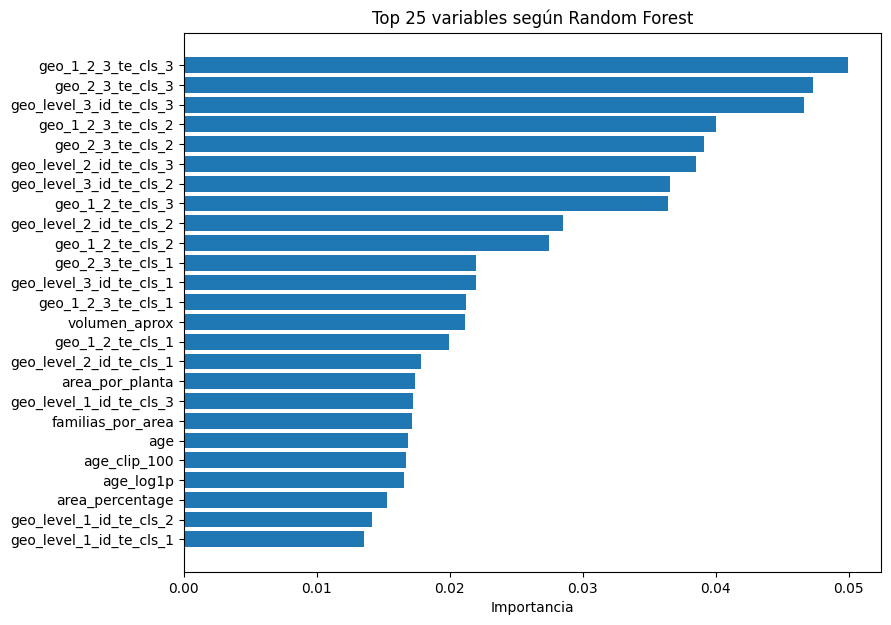

In [8]:
# ============================================================
# 10. Matriz de confusión e informe de clasificación
# ============================================================

mejor_modelo_nombre = resultados_df.loc[0, "modelo"]
mejor_pred_valid = pred_valid[mejor_modelo_nombre]

cm = confusion_matrix(y_valid, mejor_pred_valid, labels=CLASES)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASES)
disp.plot(values_format="d")
plt.title(f"Matriz de confusión - {mejor_modelo_nombre}")
plt.show()

print(classification_report(y_valid, mejor_pred_valid, labels=CLASES, digits=4))

# ============================================================
# 10.1. Importancia de variables de Random Forest
# ============================================================

rf_model = modelos_entrenados["RandomForestClassifier"]

importancias = (
    pd.DataFrame({
        "variable": preprocessor.feature_names_,
        "importancia": rf_model.feature_importances_,
    })
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

display(importancias.head(30))

plt.figure(figsize=(9, 7))
top_imp = importancias.head(25).iloc[::-1]
plt.barh(top_imp["variable"], top_imp["importancia"])
plt.title("Top 25 variables según Random Forest")
plt.xlabel("Importancia")
plt.show()


# 10. Entrenamiento final y submissions

Una vez elegido el enfoque, entreno de nuevo con todo el conjunto de entrenamiento y genero los tres CSV de envío.

In [9]:
# ============================================================
# 11. Entrenamiento final con todo el dataset
# ============================================================

X_full_raw = train_df.drop(columns=[TARGET]).copy()
y_full = train_df[TARGET].astype(int).copy()

preprocessor_final = EarthquakePreprocessor(
    classes=CLASES,
    n_splits=N_SPLITS_TARGET_ENCODING,
    smoothing=30,
    random_state=RANDOM_STATE,
)

inicio = time.time()
X_full = preprocessor_final.fit_transform(X_full_raw, y_full)
X_test = preprocessor_final.transform(test_values)
tiempo_prep_final = time.time() - inicio

print(f"X_full procesado: {X_full.shape}")
print(f"X_test procesado: {X_test.shape}")
print(f"Tiempo de preprocesamiento final: {tiempo_prep_final:.2f} s")

rf_final = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS,
    criterion="gini",
    max_features="sqrt",
    min_samples_leaf=2,
    bootstrap=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0,
)

ada_final = crear_adaboost()

print("\nEntrenando Random Forest final...")
inicio = time.time()
rf_final.fit(X_full, y_full)
print(f"Random Forest final entrenado en {time.time() - inicio:.2f} s")

print("\nEntrenando AdaBoost final...")
inicio = time.time()
ada_final.fit(X_full, y_full)
print(f"AdaBoost final entrenado en {time.time() - inicio:.2f} s")


X_full procesado: (260601, 102)
X_test procesado: (86868, 102)
Tiempo de preprocesamiento final: 10.65 s

Entrenando Random Forest final...
Random Forest final entrenado en 83.41 s

Entrenando AdaBoost final...
AdaBoost final entrenado en 137.08 s


In [10]:
# ============================================================
# 11.1. Generación de submissions
# ============================================================

def crear_submission(predicciones, nombre_fichero):
    """Crea y guarda un fichero de submission con el formato oficial."""
    submission = submission_format.copy()
    submission[TARGET] = np.asarray(predicciones, dtype=int)

    ruta = OUTPUT_DIR / nombre_fichero
    submission.to_csv(ruta, index=False)

    return submission, ruta


def proba_alineada_final(modelo, X, clases=CLASES):
    proba = modelo.predict_proba(X)
    salida = np.zeros((len(X), len(clases)), dtype=np.float32)

    for i, cls in enumerate(modelo.classes_):
        pos = np.where(clases == cls)[0][0]
        salida[:, pos] = proba[:, i]

    return salida


pred_test_rf = rf_final.predict(X_test)
pred_test_ada = ada_final.predict(X_test)

proba_test_rf = proba_alineada_final(rf_final, X_test)
proba_test_ada = proba_alineada_final(ada_final, X_test)

proba_test_ensemble = mejor_peso_rf * proba_test_rf + (1.0 - mejor_peso_rf) * proba_test_ada
pred_test_ensemble_bias = predecir_desde_proba(proba_test_ensemble * mejor_bias)

sub_rf, ruta_rf = crear_submission(pred_test_rf, "submission_01_random_forest.csv")
sub_ada, ruta_ada = crear_submission(pred_test_ada, "submission_02_adaboost.csv")
sub_ens, ruta_ens = crear_submission(pred_test_ensemble_bias, "submission_03_ensemble_rf_adaboost_bias.csv")

print("Submissions generadas:")
for ruta in [ruta_rf, ruta_ada, ruta_ens]:
    print(f"- {ruta} ({ruta.stat().st_size / 1024:.1f} KB)")

# ============================================================
# 11.2. Validación de submissions
# ============================================================

def validar_submission(submission, nombre):
    assert list(submission.columns) == list(submission_format.columns), f"{nombre}: columnas incorrectas"
    assert len(submission) == len(submission_format), f"{nombre}: número de filas incorrecto"
    assert submission[ID_COL].equals(submission_format[ID_COL]), f"{nombre}: building_id no coincide"
    assert set(submission[TARGET].unique()).issubset(set(CLASES)), f"{nombre}: clases no válidas"

    return {
        "submission": nombre,
        "filas": len(submission),
        "columnas_ok": list(submission.columns) == list(submission_format.columns),
        "ids_ok": submission[ID_COL].equals(submission_format[ID_COL]),
        "clases": sorted(submission[TARGET].unique().tolist()),
        "distribucion_predicha": submission[TARGET].value_counts(normalize=True).sort_index().round(4).to_dict(),
    }


validaciones = pd.DataFrame([
    validar_submission(sub_rf, "submission_01_random_forest.csv"),
    validar_submission(sub_ada, "submission_02_adaboost.csv"),
    validar_submission(sub_ens, "submission_03_ensemble_rf_adaboost_bias.csv"),
])

display(validaciones)
print("Todas las submissions cumplen el formato oficial.")


Submissions generadas:
- outputs/submission_01_random_forest.csv (758.8 KB)
- outputs/submission_02_adaboost.csv (758.8 KB)
- outputs/submission_03_ensemble_rf_adaboost_bias.csv (758.8 KB)


,submission,filas,columnas_ok,ids_ok,clases,distribucion_predicha
0,submission_01_random_forest.csv,86868,True,True,"[1, 2, 3]","{1: 0.0724, 2: 0.6501, 3: 0.2775}"
1,submission_02_adaboost.csv,86868,True,True,"[1, 2, 3]","{1: 0.0531, 2: 0.677, 3: 0.2698}"
2,submission_03_ensemble_rf_adaboost_bias.csv,86868,True,True,"[1, 2, 3]","{1: 0.0681, 2: 0.6497, 3: 0.2821}"


Todas las submissions cumplen el formato oficial.


# 11. Registro de envíos en DrivenData

Aunque el ensemble fue el mejor en validación local, el mejor resultado público lo dio Random Forest. Esto es normal en competiciones: la validación local orienta, pero el leaderboard público puede variar ligeramente.

| Fichero | Modelo / estrategia | Micro F1 local | Best Public Micro F1 | Ranking | Decisión |
|---|---|---:|---:|---:|---|
| `submission_01_random_forest.csv` | Random Forest | `0.752000` | **`0.7480`** | **`#549`** | Mejor envío público |
| `submission_02_adaboost.csv` | AdaBoost | `0.724852` | `0.7186` | No mejora | Descartado |
| `submission_03_ensemble_rf_adaboost_bias.csv` | Ensemble RF + AdaBoost + bias | **`0.752652`** | `0.7476` | No mejora | Mejor local, pero peor en DrivenData |


# 12. Resultado final en DrivenData

Dejo también un panel resumen para que el resultado final quede claro dentro del propio notebook.

In [11]:
# ============================================================
# 14.1. Panel final con el resultado público real de DrivenData
# ============================================================

submissions_drivendata = pd.DataFrame([
    {
        "submission": "submission_01_random_forest.csv",
        "modelo": "RandomForestClassifier",
        "micro_f1_local": 0.752000,
        "best_public_micro_f1": 0.7480,
        "ranking_final": "#549",
        "decision": "Mejor envío público",
    },
    {
        "submission": "submission_02_adaboost.csv",
        "modelo": "AdaBoostClassifier",
        "micro_f1_local": 0.724852,
        "best_public_micro_f1": 0.7186,
        "ranking_final": "No mejora el mejor score",
        "decision": "Descartado frente a Random Forest",
    },
    {
        "submission": "submission_03_ensemble_rf_adaboost_bias.csv",
        "modelo": "Ensemble_RF_AdaBoost_Bias",
        "micro_f1_local": 0.752652,
        "best_public_micro_f1": 0.7476,
        "ranking_final": "No mejora el mejor score",
        "decision": "Mejor local, pero peor en DrivenData",
    },
])

mejor_publico = submissions_drivendata.sort_values(
    "best_public_micro_f1",
    ascending=False,
).iloc[0]

resumen_final = pd.DataFrame([{
    "usuario_drivendata": "Jorgegmen",
    "mejor_submission_publica": mejor_publico["submission"],
    "modelo_mejor_publico": mejor_publico["modelo"],
    "best_public_micro_f1": mejor_publico["best_public_micro_f1"],
    "posicion_ranking": mejor_publico["ranking_final"],
    "mejor_modelo_local": "Ensemble_RF_AdaBoost_Bias",
    "mejor_micro_f1_local": 0.752652,
}])

display(submissions_drivendata)
display(resumen_final)


,submission,modelo,micro_f1_local,best_public_micro_f1,ranking_final,decision
0,submission_01_random_forest.csv,RandomForestClassifier,0.752000,0.7480,#549,Mejor envío público
1,submission_02_adaboost.csv,AdaBoostClassifier,0.724852,0.7186,No mejora el mejor score,Descartado frente a Random Forest
2,submission_03_ensemble_rf_adaboost_bias.csv,Ensemble_RF_AdaBoost_Bias,0.752652,0.7476,No mejora el mejor score,"Mejor local, pero peor en DrivenData"


,usuario_drivendata,mejor_submission_publica,modelo_mejor_publico,best_public_micro_f1,posicion_ranking,mejor_modelo_local,mejor_micro_f1_local
0,Jorgegmen,submission_01_random_forest.csv,RandomForestClassifier,0.748,#549,Ensemble_RF_AdaBoost_Bias,0.752652


# 13. Conclusiones

El mejor resultado local fue el ensemble `Ensemble_RF_AdaBoost_Bias`, con **0.752652 Micro F1**. Sin embargo, al subir los CSV a DrivenData, el mejor resultado público fue el de `submission_01_random_forest.csv`, con **0.7480 Best Public Micro F1** y posición **#549**.

Por tanto, para la entrega dejo como resultado final:

```text
Submission final: submission_01_random_forest.csv
Modelo final: RandomForestClassifier
Best Public Micro F1: 0.7480
Ranking: #549
```

La conclusión principal es que Random Forest ha sido el modelo más fiable para este caso. El ensemble consiguió una validación local ligeramente superior, pero no mejoró el resultado público, así que no conviene elegirlo como submission final.

# 14. Bibliografía y material utilizado

- Datos oficiales de la competición **Richter's Predictor: Modeling Earthquake Damage** de DrivenData.
- Material de la asignatura sobre aprendizaje supervisado, árboles de decisión, Naive Bayes, kNN, ensembles y optimización de hiperparámetros.
- Documentación oficial de las librerías utilizadas: `pandas`, `numpy`, `matplotlib` y `scikit-learn`.
